# Graph Super-Resolution Training Notebook
This notebook contains the model definition and a full 3-fold CV training pipeline in one place.

## 1) Imports and Seed
Import dependencies and set the seed for reproducibility.

In [20]:
import copy
import os
import random
import sys
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import KFold
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import DenseSAGEConv
from tqdm import tqdm


from src.data.dataset import BrainGraphDataset
from src.data.MatrixVectorizer import MatrixVectorizer
from src.eval.evaluation_measures import compute_evaluation_measures
from src.utils import set_random_seed

# Set a fixed random seed for reproducibility across multiple libraries
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# Check for CUDA (GPU support) and set device accordingly
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available. Using GPU.")
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)  # For multi-GPU setups
    # Additional settings for ensuring reproducibility on CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU.")

CUDA not available. Using CPU.


## 2) Model Definition
BiRD-Brain model

In [21]:
class BiSR(nn.Module):
    def __init__(self, in_nodes=160, out_nodes=268, feature_dim=160, hidden_dim=16, rank=8):
        super().__init__()
        self.U = nn.Parameter(torch.randn(in_nodes, rank) * 0.01)
        self.V = nn.Parameter(torch.randn(rank, out_nodes) * 0.01)
        self.W = nn.Linear(feature_dim, hidden_dim)

    def forward(self, x_l):
        x_transformed = self.W(x_l)
        B = self.U @ self.V
        x_h = torch.matmul(B.t(), x_transformed)
        return F.relu(x_h)


class EdgeMLP(nn.Module):
    def __init__(self, hidden_dim: int, num_layers: int = 1, dropout: float = 0.5):
        super().__init__()
        if num_layers == 1:
            self.net = nn.Linear(hidden_dim * 2, 1)
        else:
            layers = []
            in_dim = hidden_dim * 2
            for _ in range(num_layers - 1):
                out_dim = max(in_dim // 2, 1)
                layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
                in_dim = out_dim
            layers.append(nn.Linear(in_dim, 1))
            self.net = nn.Sequential(*layers)

    def forward(self, edge_features):
        return self.net(edge_features)


class DEFEND(nn.Module):
    def __init__(self, num_hr_nodes=268, hidden_dim=16, edge_mlp_layers=1, dropout=0.5):
        super().__init__()
        self.num_nodes = num_hr_nodes
        self.edge_mlp = EdgeMLP(hidden_dim, num_layers=edge_mlp_layers, dropout=dropout)

    def forward(self, x_h):
        batch_size = x_h.shape[0]
        row_indices, col_indices = torch.triu_indices(self.num_nodes, self.num_nodes, offset=1)
        source_features = x_h[:, row_indices, :]
        target_features = x_h[:, col_indices, :]
        edge_sum = source_features + target_features
        edge_diff = torch.abs(source_features - target_features)
        edge_features = torch.cat([edge_sum, edge_diff], dim=-1)
        predicted_edge_weights = self.edge_mlp(edge_features).squeeze(-1)

        adj_hr = torch.zeros((batch_size, self.num_nodes, self.num_nodes), device=x_h.device)
        adj_hr[:, row_indices, col_indices] = predicted_edge_weights
        adj_hr[:, col_indices, row_indices] = predicted_edge_weights
        return adj_hr


class BrainGraphSuperResolutionModel(nn.Module):
    def __init__(
        self,
        in_nodes=160,
        out_nodes=268,
        hidden_dim=16,
        gcn_layers=1,
        hidden_dim_gcn=32,
        k_threshold=0.8,
        bisr_rank=8,
        dropout=0.5,
        edge_mlp_layers=1,
    ):
        super().__init__()
        self.k_threshold = k_threshold
        self.dropout = dropout
        self.register_buffer('hr_mean', torch.zeros(out_nodes, out_nodes))
        self.num_gcn_layers = gcn_layers

        if gcn_layers == 0:
            self.gcn_layers = nn.ModuleList()
        elif gcn_layers == 1:
            self.gcn_layers = nn.ModuleList([
                DenseSAGEConv(in_channels=in_nodes, out_channels=hidden_dim_gcn),
                DenseSAGEConv(in_channels=hidden_dim_gcn, out_channels=in_nodes),
            ])
        else:
            layers = [DenseSAGEConv(in_channels=in_nodes, out_channels=hidden_dim_gcn)]
            for _ in range(gcn_layers - 1):
                layers.append(DenseSAGEConv(in_channels=hidden_dim_gcn, out_channels=hidden_dim_gcn))
            layers.append(DenseSAGEConv(in_channels=hidden_dim_gcn, out_channels=in_nodes))
            self.gcn_layers = nn.ModuleList(layers)

        self.bi_sr = BiSR(
            in_nodes=in_nodes,
            out_nodes=out_nodes,
            feature_dim=in_nodes,
            hidden_dim=hidden_dim,
            rank=bisr_rank,
        )
        self.defend = DEFEND(
            num_hr_nodes=out_nodes,
            hidden_dim=hidden_dim,
            edge_mlp_layers=edge_mlp_layers,
            dropout=dropout,
        )

    def forward(self, adj_lr):
        node_features = adj_lr
        binary_adj = (adj_lr > self.k_threshold).float()

        if self.num_gcn_layers > 0:
            for layer in self.gcn_layers:
                node_features = F.relu(layer(node_features, binary_adj))
                node_features = F.dropout(node_features, p=self.dropout, training=self.training)
            x_lr_enriched = node_features + adj_lr
        else:
            x_lr_enriched = adj_lr

        hr_node_embeddings = self.bi_sr(x_lr_enriched)
        hr_residual = self.defend(hr_node_embeddings)
        hr_adjacency_matrix = self.hr_mean + hr_residual
        hr_adjacency_matrix = torch.clamp(hr_adjacency_matrix, min=0.0, max=1.0)
        return hr_adjacency_matrix

## 3) Training Utilities
Helper functions for priors, saving fold predictions, and plotting CV metrics.

In [22]:
def compute_mean_hr_for_indices(data_dir: str, sample_indices: np.ndarray, num_nodes: int = 268) -> torch.Tensor:
    hr_df = pd.read_csv(os.path.join(data_dir, 'hr_train.csv'))
    mean_vector = hr_df.iloc[sample_indices].values.mean(axis=0)
    mean_matrix = MatrixVectorizer.anti_vectorize(mean_vector, num_nodes, include_diagonal=False)
    return torch.tensor(mean_matrix, dtype=torch.float32)


def save_fold_val_predictions(model, val_loader, device, output_dir, fold_num):
    model.eval()
    all_predictions = []
    with torch.no_grad():
        for batch in val_loader:
            lr_data, _ = batch
            num_graphs = lr_data.num_graphs
            lr_adj = lr_data.x.view(num_graphs, 160, 160).to(device)
            pred_batch = model(lr_adj).cpu().numpy()
            for pred_matrix in pred_batch:
                pred_vector = MatrixVectorizer.vectorize(pred_matrix, include_diagonal=False)
                all_predictions.append(pred_vector)

    flat_predictions = np.concatenate(all_predictions) if len(all_predictions) > 0 else np.array([])
    ids = np.arange(1, len(flat_predictions) + 1)
    submission_df = pd.DataFrame({'ID': ids, 'Predicted': flat_predictions})
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, f'predictions_fold_{fold_num}.csv')
    submission_df.to_csv(output_path, index=False)
    print(f'Saved validation predictions to {output_path}')


def plot_cv_metrics(metrics_df, output_dir):
    metric_names = ['MAE', 'PCC', 'JSD', 'Cosine Sim', 'MAE (DC)', 'MAE (PC)', 'MAE (EC)', 'MAE (BC)']
    metric_means = metrics_df[metric_names].mean()
    metric_stds = metrics_df[metric_names].std(ddof=1)

    summary_df = pd.DataFrame({
        'Metric': metric_names,
        'Mean': [metric_means[m] for m in metric_names],
        'Std': [metric_stds[m] for m in metric_names],
    })
    summary_csv_path = os.path.join(output_dir, 'cv_metrics_summary.csv')
    summary_df.to_csv(summary_csv_path, index=False)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()
    bar_colors = ['#ff6666', '#66b266', '#6666e6', '#4f9ec4', '#b57edc', '#f0c060', '#61d4d4', '#62ea62']

    def add_value_labels(ax, bars):
        y_min, y_max = ax.get_ylim()
        offset = 0.01 * (y_max - y_min if y_max > y_min else 1.0)
        for bar in bars:
            h = bar.get_height()
            x = bar.get_x() + bar.get_width() / 2.0
            if h >= 0:
                ax.text(x, h + offset, f'{h:.3f}', ha='center', va='bottom', fontsize=8)
            else:
                ax.text(x, h - offset, f'{h:.3f}', ha='center', va='top', fontsize=8)

    for i, row in metrics_df.iterrows():
        ax = axes[i]
        values = [row[m] for m in metric_names]
        bars = ax.bar(metric_names, values, color=bar_colors)
        ax.set_title(f"Fold {int(row['Fold'])}")
        ax.tick_params(axis='x', rotation=45)
        add_value_labels(ax, bars)

    avg_ax = axes[3]
    avg_values = [metric_means[m] for m in metric_names]
    avg_err = [metric_stds[m] for m in metric_names]
    avg_bars = avg_ax.bar(metric_names, avg_values, yerr=avg_err, capsize=4, color=bar_colors)
    avg_ax.set_title('Avg. Across Folds')
    avg_ax.tick_params(axis='x', rotation=45)
    add_value_labels(avg_ax, avg_bars)

    plt.tight_layout()
    plot_path = os.path.join(output_dir, 'cv_metrics_plot.png')
    plt.savefig(plot_path, dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved metrics summary to {summary_csv_path}')
    print(f'Saved CV metrics plot to {plot_path}')

## 4) Training Function
This function runs 3-fold cross-validation, saves best fold models, computes fold metrics, and exports fold predictions.

In [29]:
def train_cv(args):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    os.makedirs(args.save_dir, exist_ok=True)
    os.makedirs(args.pred_output_dir, exist_ok=True)

    full_dataset = BrainGraphDataset(
        lr_file=os.path.join(args.data_dir, 'lr_train.csv'),
        hr_file=os.path.join(args.data_dir, 'hr_train.csv'),
    )
    num_samples = len(full_dataset)
    all_indices = np.arange(num_samples)

    kf = KFold(n_splits=3, shuffle=True, random_state=args.seed)
    fold_metrics = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(all_indices), start=1):
        print(f'\n===== Fold {fold_num}/3 =====')
        train_subset = Subset(full_dataset, train_idx)
        val_subset = Subset(full_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=args.batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_subset, batch_size=args.batch_size, shuffle=False, num_workers=0)

        hr_mean = compute_mean_hr_for_indices(args.data_dir, train_idx)
        model = BrainGraphSuperResolutionModel(
            in_nodes=160,
            out_nodes=268,
            hidden_dim=args.hidden_dim,
            gcn_layers=args.gcn_layers,
            hidden_dim_gcn=args.hidden_dim_gcn,
            k_threshold=args.k_threshold,
            bisr_rank=args.bisr_rank,
            dropout=args.dropout,
            edge_mlp_layers=args.edge_mlp_layers,
        ).to(device)
        model.hr_mean.copy_(hr_mean.to(device))

        criterion = nn.L1Loss()
        optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=args.patience
        )

        best_val_loss = float('inf')
        best_state_dict = copy.deepcopy(model.state_dict())

        for epoch in range(1, args.epochs + 1):
            model.train()
            train_loss = 0.0
            should_print = (epoch % 20 == 0 or epoch == args.epochs)
            pbar = tqdm(train_loader, desc=f'Fold {fold_num} Epoch {epoch}/{args.epochs} [Train]', disable=not should_print)

            for batch in pbar:
                lr_data, hr_data = batch
                num_graphs = lr_data.num_graphs
                lr_adj = lr_data.x.view(num_graphs, 160, 160).to(device)
                hr_adj_target = hr_data.x.view(num_graphs, 268, 268).to(device)

                if args.noise_std > 0:
                    lr_adj = lr_adj + torch.randn_like(lr_adj) * args.noise_std

                optimizer.zero_grad()
                hr_adj_pred = model(lr_adj)
                loss = criterion(hr_adj_pred, hr_adj_target)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * num_graphs
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            train_loss /= len(train_loader.dataset)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    lr_data, hr_data = batch
                    num_graphs = lr_data.num_graphs
                    lr_adj = lr_data.x.view(num_graphs, 160, 160).to(device)
                    hr_adj_target = hr_data.x.view(num_graphs, 268, 268).to(device)

                    hr_adj_pred = model(lr_adj)
                    loss = criterion(hr_adj_pred, hr_adj_target)
                    val_loss += loss.item() * num_graphs

            val_loss /= len(val_loader.dataset)
            scheduler.step(val_loss)
            if epoch % 20 == 0 or epoch == args.epochs:
                print(
                    f'Fold {fold_num} Epoch {epoch} | '
                    f'Train: {train_loss:.6f} | Val: {val_loss:.6f}'
                )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state_dict = copy.deepcopy(model.state_dict())
                base, ext = os.path.splitext(args.model_name)
                fold_model_name = f"{base}_fold{fold_num}{ext or '.pth'}"
                checkpoint_path = os.path.join(args.save_dir, fold_model_name)
                torch.save(best_state_dict, checkpoint_path)

        model.load_state_dict(best_state_dict)

        pred_matrices, gt_matrices = [], []
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                lr_data, hr_data = batch
                num_graphs = lr_data.num_graphs
                lr_adj = lr_data.x.view(num_graphs, 160, 160).to(device)
                hr_adj_target = hr_data.x.view(num_graphs, 268, 268)
                hr_adj_pred = model(lr_adj).cpu()
                pred_matrices.extend(hr_adj_pred.numpy())
                gt_matrices.extend(hr_adj_target.numpy())

        metrics_raw = compute_evaluation_measures(pred_matrices, gt_matrices)
        metrics_fold = {
            'Fold': fold_num,
            'MAE': metrics_raw['MAE'],
            'PCC': metrics_raw['PCC'],
            'JSD': metrics_raw['Jensen-Shannon Distance'],
            'Cosine Sim': metrics_raw['Cosine Similarity'],
            'MAE (DC)': metrics_raw['Average MAE degree centrality'],
            'MAE (PC)': metrics_raw['Average MAE PageRank centrality'],
            'MAE (EC)': metrics_raw['Average MAE eigenvector centrality'],
            'MAE (BC)': metrics_raw['Average MAE betweenness centrality'],
        }
        fold_metrics.append(metrics_fold)

        save_fold_val_predictions(model, val_loader, device, args.pred_output_dir, fold_num)

    metrics_df = pd.DataFrame(fold_metrics)
    metrics_csv_path = os.path.join(args.pred_output_dir, 'cv_fold_metrics.csv')
    metrics_df.to_csv(metrics_csv_path, index=False)
    print(f'Saved fold metrics to {metrics_csv_path}')

    plot_cv_metrics(metrics_df, args.pred_output_dir)
    print('3-fold cross-validation training complete!')

## 5) Run Configuration
Set your hyperparameters and data paths here.

In [ ]:
args = SimpleNamespace(
    data_dir='datasets',
    batch_size=16,
    epochs=200,
    lr=0.001,
    weight_decay=1e-2,
    save_dir='models',
    model_name='best_model.pth',
    pred_output_dir='evaluation_results',
    k_threshold=0.8,
    patience=20,
    gcn_layers=1,
    hidden_dim=16,
    hidden_dim_gcn=32,
    bisr_rank=8,
    edge_mlp_layers=1,
    dropout=0.5,
    noise_std=0.01,
    seed = random_seed,
)
args

namespace(data_dir='datasets',
          batch_size=16,
          epochs=200,
          lr=0.001,
          weight_decay=0.01,
          save_dir='model',
          model_name='best_model.pth',
          pred_output_dir='evaluation_results',
          k_threshold=0.8,
          patience=20,
          gcn_layers=1,
          hidden_dim=16,
          hidden_dim_gcn=32,
          bisr_rank=8,
          edge_mlp_layers=1,
          dropout=0.5,
          noise_std=0.01,
          seed=42)

## 6) Start Training
Run this cell to launch 3-fold CV training.

Using device: cpu

===== Fold 1/3 =====


Fold 1 Epoch 20/200 [Train]: 100%|██████████| 7/7 [00:00<00:00, 14.04it/s, loss=0.1391]


Fold 1 Epoch 20 | Train: 0.135938 | Val: 0.131949


Fold 1 Epoch 40/200 [Train]: 100%|██████████| 7/7 [00:00<00:00, 14.11it/s, loss=0.1350]


Fold 1 Epoch 40 | Train: 0.135117 | Val: 0.131289


...

Fold 3 Epoch 160 | Train: 0.140310 | Val: 0.140206


Fold 3 Epoch 180/200 [Train]: 100%|██████████| 7/7 [00:00<00:00, 13.05it/s, loss=0.1427]


Fold 3 Epoch 180 | Train: 0.140309 | Val: 0.140206


Fold 3 Epoch 200/200 [Train]: 100%|██████████| 7/7 [00:00<00:00, 10.96it/s, loss=0.1416]


Fold 3 Epoch 200 | Train: 0.140309 | Val: 0.140206
MAE: 0.1407303363084793
PCC: 0.6239417791366577
Jensen-Shannon Distance: 0.2875521183013916
Cosine Similarity: 0.8610573410987854
Average MAE degree centrality: 0.19437541607590242
Average MAE betweenness centrality: 0.022346856652707647
Average MAE eigenvector centrality: 0.01320631319511072
Average MAE PageRank centrality: 0.000557450715609394
Saved validation predictions to evaluation_results/predictions_fold_3.csv
Saved fold metrics to evaluation_results/cv_fold_metrics.csv


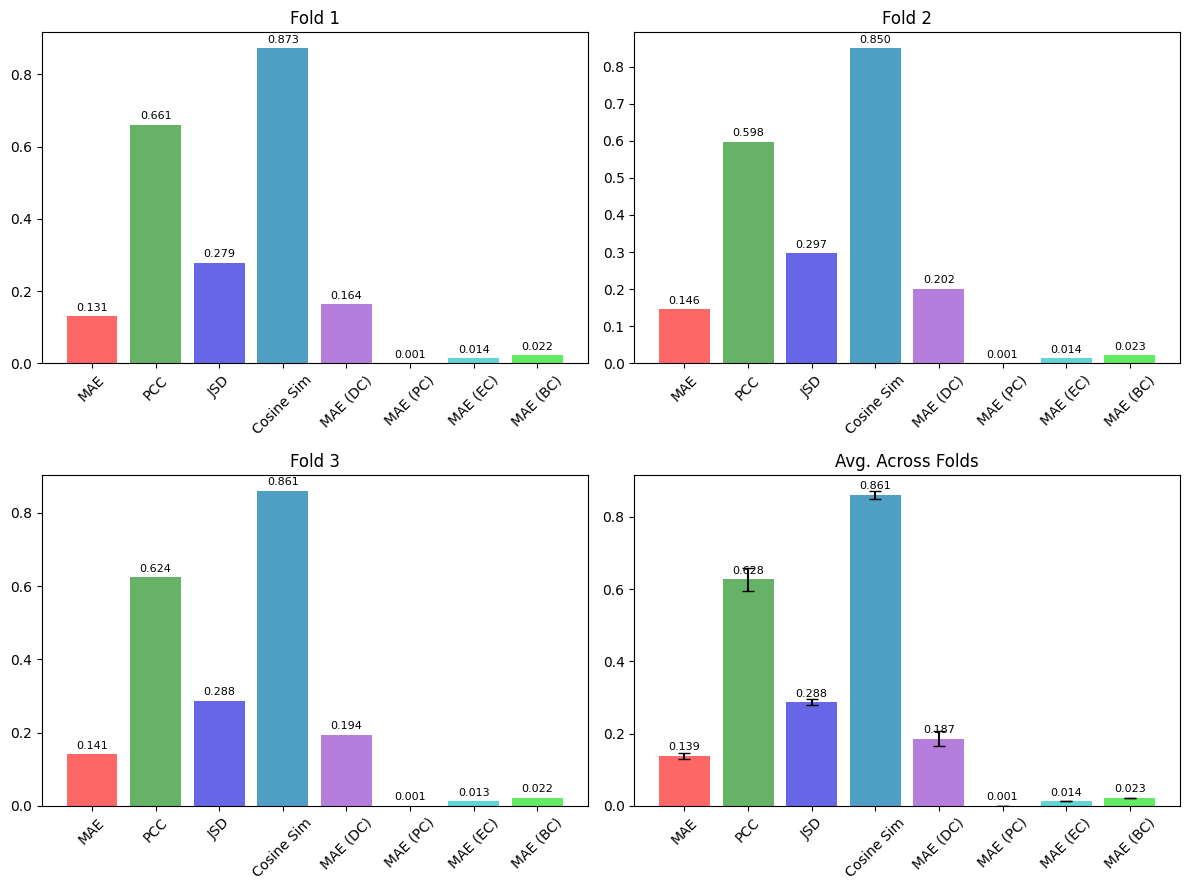

Saved metrics summary to evaluation_results/cv_metrics_summary.csv
Saved CV metrics plot to evaluation_results/cv_metrics_plot.png
3-fold cross-validation training complete!


In [31]:
train_cv(args)

## 7) Test Prediction with Best Fold Model
This cell picks the best fold model (lowest validation MAE), predicts on `lr_test.csv`, flattens outputs, and saves a submission-style CSV.

In [ ]:
# Select best fold from CV metrics and run test prediction
base, ext = os.path.splitext(args.model_name)
metrics_path = os.path.join(args.pred_output_dir, 'cv_fold_metrics.csv')

if not os.path.exists(metrics_path):
    raise FileNotFoundError(f'Could not find {metrics_path}. Run train_cv(args) first.')

metrics_df = pd.read_csv(metrics_path)
best_fold = int(metrics_df.loc[metrics_df['MAE'].idxmin(), 'Fold'])
best_model_path = os.path.join(args.save_dir, f"{base}_fold{best_fold}{ext or '.pth'}")

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f'Best fold model not found at {best_model_path}')

print(f'Using best fold: {best_fold}')
print(f'Loading model from: {best_model_path}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BrainGraphSuperResolutionModel(
    in_nodes=160,
    out_nodes=268,
    hidden_dim=args.hidden_dim,
    gcn_layers=args.gcn_layers,
    hidden_dim_gcn=args.hidden_dim_gcn,
    k_threshold=args.k_threshold,
    bisr_rank=args.bisr_rank,
    dropout=args.dropout,
    edge_mlp_layers=args.edge_mlp_layers,
).to(device)

# Set hr_mean using all training samples for final test inference
all_train_indices = np.arange(len(pd.read_csv(os.path.join(args.data_dir, 'hr_train.csv'))))
hr_mean_all = compute_mean_hr_for_indices(args.data_dir, all_train_indices)
model.hr_mean.copy_(hr_mean_all.to(device))

model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model.eval()

# Load lr_test and predict
lr_test_path = os.path.join(args.data_dir, 'lr_test.csv')
if not os.path.exists(lr_test_path):
    raise FileNotFoundError(f'Could not find {lr_test_path}')

lr_test_df = pd.read_csv(lr_test_path)
all_predictions = []

with torch.no_grad():
    for i in tqdm(range(len(lr_test_df)), desc='Predicting test set'):
        lr_vector = lr_test_df.iloc[i].values
        lr_matrix = MatrixVectorizer.anti_vectorize(lr_vector, 160, include_diagonal=False)
        lr_tensor = torch.tensor(lr_matrix, dtype=torch.float32).unsqueeze(0).to(device)

        pred_matrix = model(lr_tensor).squeeze(0).cpu().numpy()
        pred_vector = MatrixVectorizer.vectorize(pred_matrix, include_diagonal=False)
        all_predictions.append(pred_vector)

flat_predictions = np.concatenate(all_predictions) if len(all_predictions) > 0 else np.array([])
ids = np.arange(1, len(flat_predictions) + 1)
pred_df = pd.DataFrame({'ID': ids, 'Predicted': flat_predictions})

os.makedirs(args.pred_output_dir, exist_ok=True)
out_path = os.path.join(args.pred_output_dir, 'predictions_test.csv')
pred_df.to_csv(out_path, index=False)
print(f'Saved test predictions to {out_path}')

Using best fold: 1
Loading model from: src/dual/models/best_model_fold1.pth


Using best fold: 1
Loading model from: src/dual/models/best_model_fold1.pth


Predicting test set: 100%|██████████| 112/112 [00:02<00:00, 46.56it/s]


Using best fold: 1
Loading model from: src/dual/models/best_model_fold1.pth


Predicting test set: 100%|██████████| 112/112 [00:02<00:00, 46.56it/s]


Saved test predictions to src/dual/evaluation_results/predictions_test_best_fold.csv
